In [1]:
import traded_player_performance as tra

players = tra.find_traded_players(team = 'Seattle')
players

,Name,Years,Teams,PA_Seattle,PA_previous,AB_Seattle,AB_previous,HR/PA_diff,SLG_diff,BA_diff,OBP_diff
0,Miguel Batista,2009 -> 2010,to Washington,1,9,1,8,0.000000,-0.125,-0.125,-0.125
1,Adrian Beltr\xc3\xa9,2009 -> 2010,to Boston,477,641,449,589,-0.026910,-0.174,-0.056,-0.061
2,Russell Branyan,2008 -> 2009,from Milwaukee,505,152,431,132,-0.017561,-0.063,0.001,0.005
3,Endy Ch\xc3\xa1vez,2008 -> 2009,from New York,182,298,161,270,0.007633,0.012,0.006,0.020
4,Ken Griffey Jr.,2008 -> 2009,"from Chicago,Cincinnati",454,575,387,490,0.010546,-0.013,-0.035,-0.029
...,...,...,...,...,...,...,...,...,...,...,...
176,Brendan Donovan,2025 -> 2026,from St. Louis,101,515,84,460,0.010285,0.030,-0.013,0.033
177,Connor Joe,2025 -> 2026,"from Cincinnati,San Diego",45,80,39,70,0.022222,0.065,-0.007,0.026
178,Jhonny Pereda,2025 -> 2026,"from Athletics,Minnesota",68,78,63,69,0.029412,0.032,0.024,-0.001
179,Rob Refsnyder,2025 -> 2026,from Boston,119,215,105,187,-0.016650,-0.252,-0.129,-0.146


Average HR/PA difference: -0.0011977961317393587
Average BA difference: -0.00529834254143647
Average OBP difference: -0.007149171270718231
Average SLG difference: -0.01869060773480663


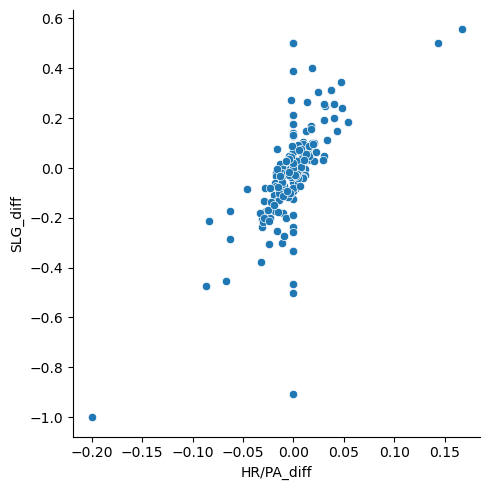

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(data = players, x = 'HR/PA_diff', y = 'SLG_diff')
print('Average HR/PA difference:', players['HR/PA_diff'].mean())
print('Average BA difference:', players['BA_diff'].mean())
print('Average OBP difference:', players['OBP_diff'].mean())
print('Average SLG difference:', players['SLG_diff'].mean())

In [34]:
df_ken = players[players['Name'] == 'Ken Griffey Jr.']
print(df_ken)

print(df_ken['SLG_diff'].iloc[0])

assert df_ken['Teams'].iloc[0] == 'from Chicago,Cincinnati'
assert df_ken['Years'].iloc[0] == '2008 -> 2009'
assert df_ken['PA_Seattle'].iloc[0] == 454
assert df_ken['PA_previous'].iloc[0] == 575
assert df_ken['AB_Seattle'].iloc[0] == 387
assert df_ken['AB_previous'].iloc[0] == 490

assert -0.03 >= df_ken['BA_diff'].iloc[0] >= -0.04
assert -0.01 >= df_ken['SLG_diff'].iloc[0] >= -0.02
assert -0.02 >= df_ken['OBP_diff'].iloc[0] >= -0.03

              Name         Years                    Teams  PA_Seattle  \
4  Ken Griffey Jr.  2008 -> 2009  from Chicago,Cincinnati         454   

   PA_previous  AB_Seattle  AB_previous  HR/PA_diff  SLG_diff  BA_diff  \
4          575         387          490    0.010546    -0.013   -0.035   

   OBP_diff  
4    -0.029  
-0.013000000000000012


In [9]:
import pybaseball
from pybaseball import batting_stats_bref

df = batting_stats_bref(2025)
df.columns

Index(['Name', 'Age', '#days', 'Lev', 'Tm', 'G', 'PA', 'AB', 'R', 'H', '2B',
       '3B', 'HR', 'RBI', 'BB', 'IBB', 'SO', 'HBP', 'SH', 'SF', 'GDP', 'SB',
       'CS', 'BA', 'OBP', 'SLG', 'OPS', 'mlbID'],
      dtype='object')

In [71]:
from pybaseball import get_splits

# find the split stats for Mike Trout
df = get_splits('troutmi01')  # career, since no year was specified
print(df.shape)
print(df.index.names)
print(df.index.get_level_values(0).unique())
print(df.loc['Ballparks'])

(232, 28)
['Split Type', 'Split']
Index(['Season Totals', 'Platoon Splits', 'Home or Away',
       'First or Second Half', 'Months', 'Game Outcome for Team',
       'Starter or Substitute', 'Defensive Positions', 'Leading Off Inning',
       'Batting Order Positions', 'Swung or Took First Pitch of PA',
       'Count/Balls-Strikes', 'Number of Outs in Inning', 'Bases Occupied',
       'Clutch Stats', 'Leverage', 'Times Facing Opponent in Game',
       'vs. Power/Finesse Pitchers', 'vs. Ground Ball/Fly Ball Pitchers',
       'Hit Location', 'Hit Trajectory', 'Opponent', 'Game Conditions',
       'Ballparks'],
      dtype='object', name='Split Type')
                      G   GS    PA    AB    R    H   2B  3B   HR  RBI  ...  \
Split                                                                  ...   
LAA-Angel Stad      869  862  3716  3031  619  888  155  27  210  489  ...   
ARI-Chase Field       5    5    21    19    4    8    3   1    2    5  ...   
STL-Busch Stad 3      8    8    

/opt/anaconda3/lib/python3.12/site-packages/pybaseball/split_stats.py:71: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  commentsoup = bs.BeautifulSoup(comment[i], 'lxml')


In [ ]:
import pybaseball
from pybaseball import batting_stats_bref, get_splits, playerid_reverse_lookup
import pandas as pd
import time

pybaseball.cache.enable()

def home_away_splits(start_year, end_year, team: str = 'Seattle') -> pd.DataFrame:
    home_tot = []
    away_tot = []
    print('Running')
    print('...')
    for year in range(start_year, end_year + 1):
        time.sleep(1)
        this_year = batting_stats_bref(year)
        players_this_year = this_year[this_year['Tm'] == team]

        mlb_ids = list(players_this_year['mlbID'])
        ids = playerid_reverse_lookup(mlb_ids, key_type='mlbam')

        for i in players_this_year.index:

            d_home = {}
            d_away = {}

            row = players_this_year.loc[i]
            name = row['Name']
            mlb_id = row['mlbID']

            match = ids[ids['key_mlbam'] == mlb_id]
            bbref_id = match['key_bbref'].iloc[0]

            time.sleep(1)
            df = get_splits(bbref_id, year=year)

            home_away = df.loc['Home or Away']
            home_away = home_away.reset_index()

            home_away['Name'] = name
            home_away['Year'] = year

            home = home_away[home_away['Split'] == 'Home']
            away = home_away[home_away['Split'] == 'Away']

            if (len(home['G']) > 0) and (len(away['G']) > 0):

                g = home['G'].iloc[0]
                gs = home['GS'].iloc[0]
                pa = home['PA'].iloc[0]
                ab = home['AB'].iloc[0]
                r = home['R'].iloc[0]
                h = home['H'].iloc[0]
                twb = home['2B'].iloc[0]
                thb = home['3B'].iloc[0]
                rbi = home['RBI'].iloc[0]
                sb = home['SB'].iloc[0]
                cs = home['CS'].iloc[0]
                bb = home['BB'].iloc[0]
                so = home['SO'].iloc[0]
                tb = home['TB'].iloc[0]
                gdp = home['GDP'].iloc[0]
                hbp = home['HBP'].iloc[0]
                sh = home['SH'].iloc[0]
                sf = home['SF'].iloc[0]
                ibb = home['IBB'].iloc[0]
                roe = home['ROE'].iloc[0]
                ob = home['1B'].iloc[0]

                d_home['Name'] = name
                d_home['G'] = g
                d_home['GS'] = gs
                d_home['PA'] = pa
                d_home['AB'] = ab
                d_home['R'] = r
                d_home['H'] = h
                d_home['2B'] = twb
                d_home['3B'] = thb
                d_home['RBI'] = rbi
                d_home['SB'] = sb
                d_home['CS'] = cs
                d_home['BB'] = bb
                d_home['SO'] = so
                d_home['TB'] = tb
                d_home['GDP'] = gdp
                d_home['HBP'] = hbp
                d_home['SH'] = sh
                d_home['SF'] = sf
                d_home['IBB'] = ibb
                d_home['ROE'] = roe
                d_home['1B'] = ob

                g = away['G'].iloc[0]
                gs = away['GS'].iloc[0]
                pa = away['PA'].iloc[0]
                ab = away['AB'].iloc[0]
                r = away['R'].iloc[0]
                h = away['H'].iloc[0]
                twb = away['2B'].iloc[0]
                thb = away['3B'].iloc[0]
                rbi = away['RBI'].iloc[0]
                sb = away['SB'].iloc[0]
                cs = away['CS'].iloc[0]
                bb = away['BB'].iloc[0]
                so = away['SO'].iloc[0]
                tb = away['TB'].iloc[0]
                gdp = away['GDP'].iloc[0]
                hbp = away['HBP'].iloc[0]
                sh = away['SH'].iloc[0]
                sf = away['SF'].iloc[0]
                ibb = away['IBB'].iloc[0]
                roe = away['ROE'].iloc[0]
                ob = away['1B'].iloc[0]

                d_away['Name'] = name
                d_away['G'] = g
                d_away['GS'] = gs
                d_away['PA'] = pa
                d_away['AB'] = ab
                d_away['R'] = r
                d_away['H'] = h
                d_away['2B'] = twb
                d_away['3B'] = thb
                d_away['RBI'] = rbi
                d_away['SB'] = sb
                d_away['CS'] = cs
                d_away['BB'] = bb
                d_away['SO'] = so
                d_away['TB'] = tb
                d_away['GDP'] = gdp
                d_away['HBP'] = hbp
                d_away['SH'] = sh
                d_away['SF'] = sf
                d_away['IBB'] = ibb
                d_away['ROE'] = roe
                d_away['1B'] = ob

                home_tot.append(d_home)
                away_tot.append(d_away)

    # reproduce rate stats from raw counts to correctly weight by PA or AB
    home_tot = pd.DataFrame(home_tot)
    away_tot = pd.DataFrame(away_tot)

    c_home = home_tot.groupby(['Name']).sum()
    c_away = away_tot.groupby(['Name']).sum()

    # recompute rate stats
    c_home['BA'] = c_home['H'] / c_home['AB']
    c_home['OBP'] = (c_home['H'] + c_home['BB'] + c_home['HBP']) / (
        c_home['AB'] + c_home['BB'] + c_home['HBP'] + c_home['SF'])
    c_home['SLG'] = c_home['TB'] / c_home['AB']
    c_home['OPS'] = c_home['OBP'] + c_home['SLG']
    c_home['Split'] = 'Home'

    c_away['BA'] = c_away['H'] / c_away['AB']
    c_away['OBP'] = (c_away['H'] + c_away['BB'] + c_away['HBP']) / (
        c_away['AB'] + c_away['BB'] + c_away['HBP'] + c_away['SF'])
    c_away['SLG'] = c_away['TB'] / c_away['AB']
    c_away['OPS'] = c_away['OBP'] + c_away['SLG']
    c_away['Split'] = 'Away'

    print('Done')
    return c_home, c_away

home, away = home_away_splits(2008, 2025)

Running
...


/opt/anaconda3/lib/python3.12/site-packages/pybaseball/split_stats.py:71: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  commentsoup = bs.BeautifulSoup(comment[i], 'lxml')
/opt/anaconda3/lib/python3.12/site-packages/pybaseball/split_stats.py:71: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  commentsoup = bs.BeautifulSoup(comment[i], 'lxml')
/opt/anaconda3/lib/python3.12/site-packages/pybaseball/split_stats.py:71: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  commentsoup = bs.BeautifulSoup(comment[i], 'lxml')
/opt/anaconda3/lib/python3.12/site-packages/pybaseball/split_stats.py:71: MarkupResemblesLocatorWarning: The input looks more like a filename than m

In [111]:
away

,G,GS,PA,AB,R,H,2B,3B,RBI,SB,...,SH,SF,IBB,ROE,1B,BA,OBP,SLG,OPS,Split
Name,,,,,,,,,,,,,,,,,,,,,
Ben Williamson,51,47,184,173,24,45,7,0,11,3,...,1,0,0,1,37,0.260116,0.300546,0.317919,0.618466,Away
Cade Marlowe,4,0,3,3,0,0,0,0,0,0,...,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,Away
Cal Raleigh,156,149,688,594,104,150,22,0,125,11,...,0,5,12,1,73,0.252525,0.347384,0.567340,0.914724,Away
Cole Young,37,33,132,119,11,27,5,0,16,0,...,0,2,1,0,19,0.226891,0.287879,0.344538,0.632417,Away
Dominic Canzone,76,60,234,209,30,59,7,0,26,2,...,0,3,0,0,39,0.282297,0.343348,0.502392,0.845740,Away
Dylan Moore,71,57,244,201,40,50,20,1,31,19,...,1,4,0,3,21,0.248756,0.362140,0.477612,0.839752,Away
Harry Ford,3,0,3,2,1,0,0,0,0,0,...,0,0,0,0,0,0.000000,0.333333,0.000000,0.333333,Away
J.P. Crawford,132,128,581,502,66,126,19,2,52,5,...,3,1,0,1,92,0.250996,0.347751,0.374502,0.722253,Away
Jason Vosler,5,4,18,17,1,3,0,1,3,0,...,0,0,0,0,2,0.176471,0.222222,0.294118,0.516340,Away


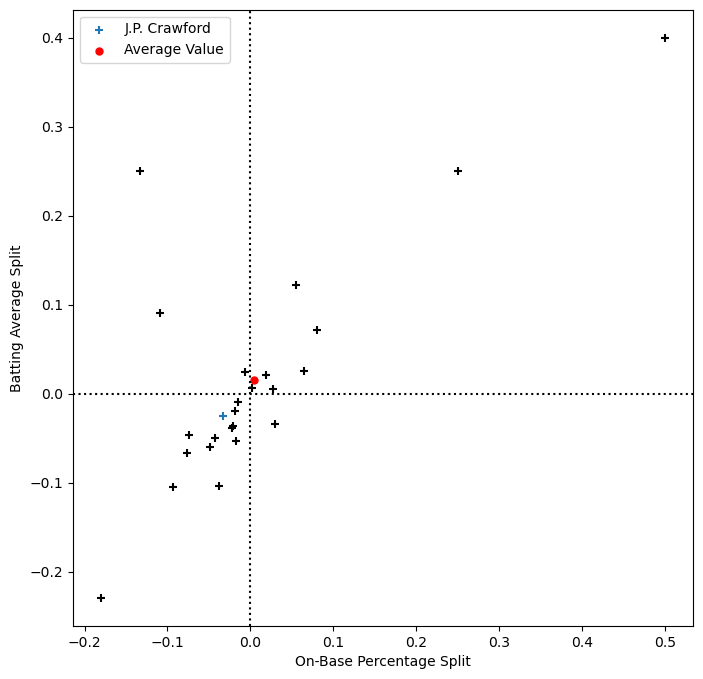

In [115]:
import numpy as np

def find_split(home_stats, away_stats, stat, min_PA: int = 0, min_AB: int = 0):

    output = []

    for i in home_stats.index:

                # need to loop through each row which is a unique player.
                home = home_stats.loc[i]
                away = away_stats.loc[i]

                if (home['PA'] >= min_PA
                    and away['PA'] >= min_PA
                    and home['AB'] >= min_AB
                    and away['AB'] >= min_AB):

                    output.append({
                            'Name': i,
                            f'{stat}_diff': (home[stat] - away[stat])})

    return pd.DataFrame(output)

stat1 = 'BA'
stat2 = 'OBP'

df = find_split(home, away, stat1, min_PA=0)
df2 = find_split(home, away, stat2, min_PA=0)

mark = ['J.P. Crawford']

fig, ax = plt.subplots(1, figsize = (8,8))

xs = []
ys =[]

for i in range(len(df)):
    y = df.loc[i][stat1 + '_diff']
    x = df2.loc[i][stat2 + '_diff']
    if df.loc[i]['Name'] in mark:

        ax.scatter(x, y, label=f'{df.loc[i]['Name']}', marker='+', s = 30, zorder=5)
    else:
        ax.scatter(x, y, color='k', marker='+', s = 30)

    xs.append(x)
    ys.append(y)

ax.scatter(np.mean(xs), np.mean(ys), color = 'r', label = 'Average Value', marker = '.', s = 100)
        
ax.axvline(0.0, color = 'k', linestyle = ':')
ax.axhline(0.0, color = 'k', linestyle = ':')

ax.set_xlabel('On-Base Percentage Split')
ax.set_ylabel('Batting Average Split')

plt.legend()
plt.show()


